In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("pizza_sales.csv")

print(df.head())
print(df.info())
print(df.shape)

   pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0         1         1     hawaiian_m         1  01-01-2015   11:38:36   
1         2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2         3         2  five_cheese_l         1  01-01-2015   11:57:40   
3         4         2    ital_supr_l         1  01-01-2015   11:57:40   
4         5         2     mexicana_m         1  01-01-2015   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2  Mozzarella Cheese, Provolone Cheese, Smoked Go...   


In [5]:
print(df.isnull().sum())

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


In [7]:
df = df.drop_duplicates()

In [13]:
print(df.head())

   pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0         1         1     hawaiian_m         1  01-01-2015   11:38:36   
1         2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2         3         2  five_cheese_l         1  01-01-2015   11:57:40   
3         4         2    ital_supr_l         1  01-01-2015   11:57:40   
4         5         2     mexicana_m         1  01-01-2015   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, Red Onions, Red Peppers,...   
2  Mozzarella Cheese, Provolone Cheese, Smoked Go...   


In [15]:
print(df.describe())

           pizza_id      order_id      quantity    unit_price   total_price
count  48620.000000  48620.000000  48620.000000  48620.000000  48620.000000
mean   24310.500000  10701.479761      1.019622     16.494132     16.821474
std    14035.529381   6180.119770      0.143077      3.621789      4.437398
min        1.000000      1.000000      1.000000      9.750000      9.750000
25%    12155.750000   5337.000000      1.000000     12.750000     12.750000
50%    24310.500000  10682.500000      1.000000     16.500000     16.500000
75%    36465.250000  16100.000000      1.000000     20.250000     20.500000
max    48620.000000  21350.000000      4.000000     35.950000     83.000000


In [17]:
print("Pizza Categories:", df['pizza_category'].unique())
print("Pizza Sizes:", df['pizza_size'].unique())

Pizza Categories: ['Classic' 'Veggie' 'Supreme' 'Chicken']
Pizza Sizes: ['M' 'L' 'S' 'XL' 'XXL']


## KPI CALCULATIONS

In [20]:
total_revenue = df['total_price'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 817860.05


In [22]:
total_orders = df['order_id'].nunique()

avg_order_value = total_revenue / total_orders

print("Average Order Value:", avg_order_value)

Average Order Value: 38.30726229508197


In [24]:
total_pizzas_sold = df['quantity'].sum()

print("Total Pizzas Sold:", total_pizzas_sold)

Total Pizzas Sold: 49574


In [26]:
print("Total Orders:", total_orders)

Total Orders: 21350


In [28]:
avg_pizzas_per_order = total_pizzas_sold / total_orders

print("Average Pizzas Per Order:", avg_pizzas_per_order)

Average Pizzas Per Order: 2.321967213114754


In [34]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
#df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')

In [36]:
df['day_name'] = df['order_date'].dt.day_name()
df['month_name'] = df['order_date'].dt.month_name()
df['month'] = df['order_date'].dt.month

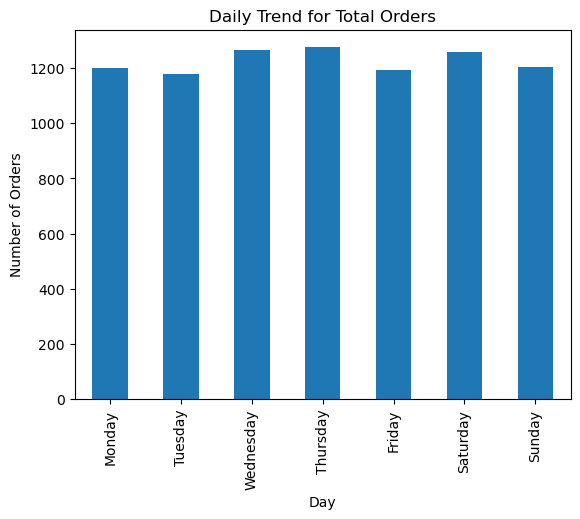

In [38]:
daily_orders = df.groupby('day_name')['order_id'].nunique()

daily_orders = daily_orders.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

daily_orders.plot(kind='bar')

plt.title("Daily Trend for Total Orders")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.show()

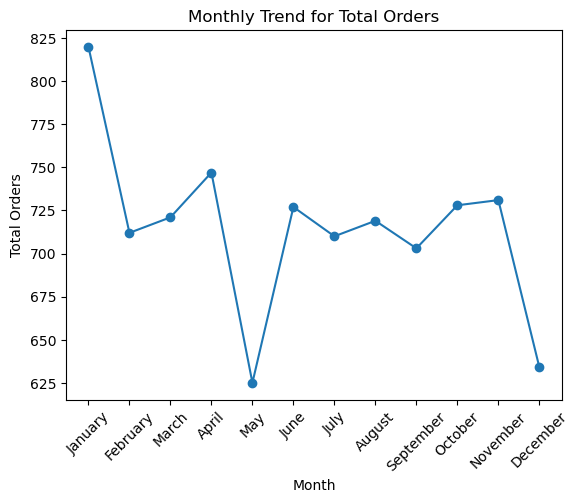

In [64]:
monthly = df.groupby(["month","month_name"])["order_id"].nunique().reset_index()

# Sort months in correct order
monthly = monthly.sort_values("month")

plt.figure()
plt.plot(monthly["month_name"], monthly["order_id"], marker='o')

plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.title("Monthly Trend for Total Orders")
plt.xticks(rotation=45)

plt.show()

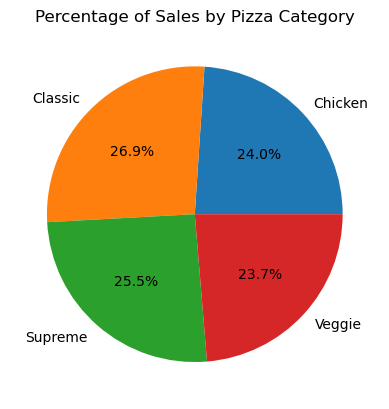

In [42]:
category_sales = df.groupby('pizza_category')['total_price'].sum()

plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')

plt.title("Percentage of Sales by Pizza Category")
plt.show()

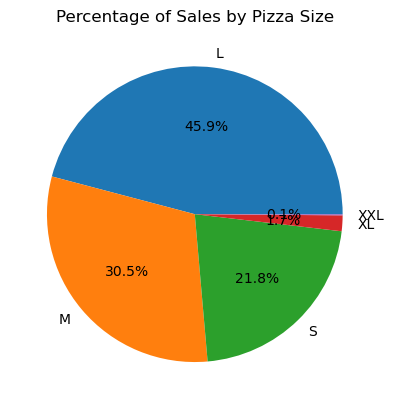

In [44]:
size_sales = df.groupby('pizza_size')['total_price'].sum()

plt.pie(size_sales, labels=size_sales.index, autopct='%1.1f%%')

plt.title("Percentage of Sales by Pizza Size")
plt.show()

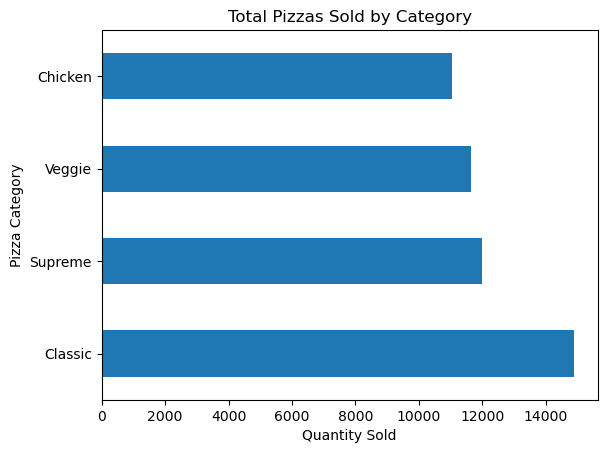

In [46]:
category_qty = df.groupby('pizza_category')['quantity'].sum().sort_values(ascending=False)

category_qty.plot(kind='barh')

plt.title("Total Pizzas Sold by Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Pizza Category")
plt.show()

pizza_category
Chicken    195919.50
Classic    220053.10
Supreme    208197.00
Veggie     193690.45
Name: total_price, dtype: float64


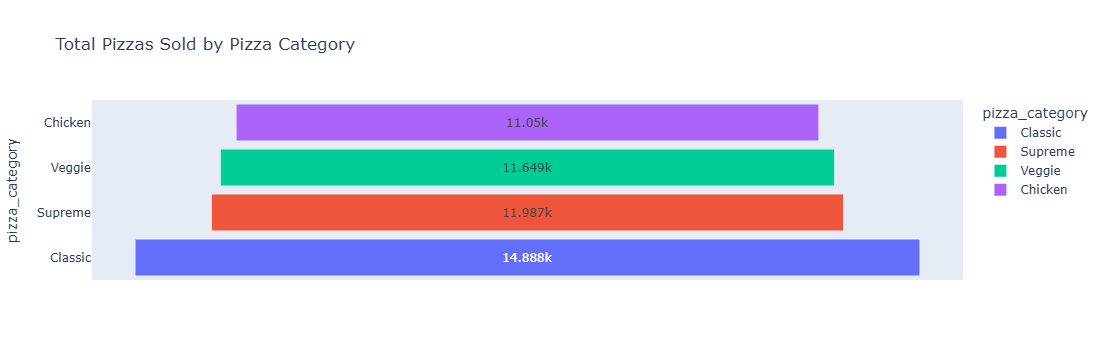

In [80]:
category_quantity = df.groupby('pizza_category')['quantity'].sum().reset_index()

print(category_sales)
import plotly.express as px
fig = px.funnel(
    category_quantity.sort_values(by='quantity', ascending=False),
    x='quantity',
    y='pizza_category',
    color='pizza_category',
    title='Total Pizzas Sold by Pizza Category'
)

fig.show()

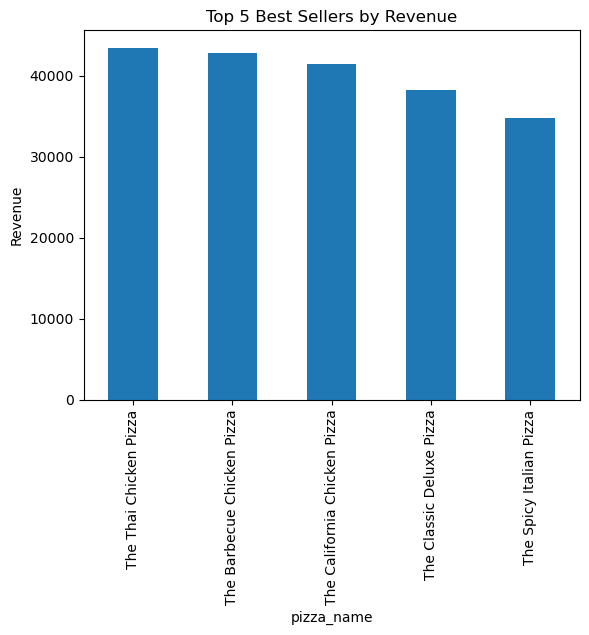

In [48]:
top5_revenue = df.groupby('pizza_name')['total_price'].sum().sort_values(ascending=False).head(5)

top5_revenue.plot(kind='bar')

plt.title("Top 5 Best Sellers by Revenue")
plt.ylabel("Revenue")
plt.show()

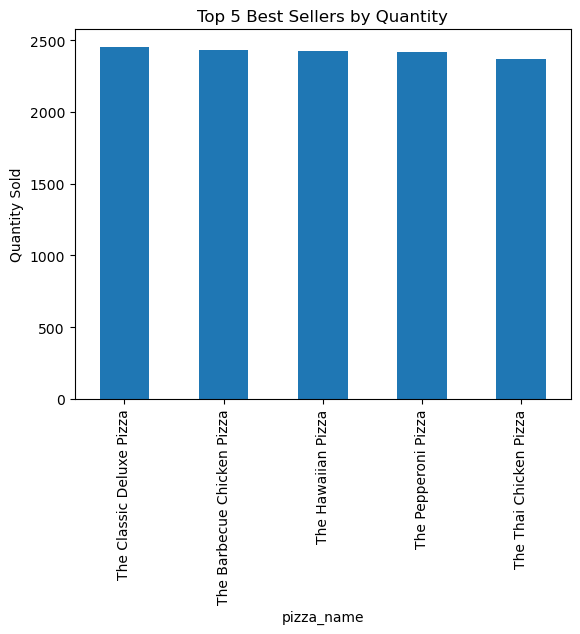

In [50]:
top5_quantity = df.groupby('pizza_name')['quantity'].sum().sort_values(ascending=False).head(5)

top5_quantity.plot(kind='bar')

plt.title("Top 5 Best Sellers by Quantity")
plt.ylabel("Quantity Sold")
plt.show()

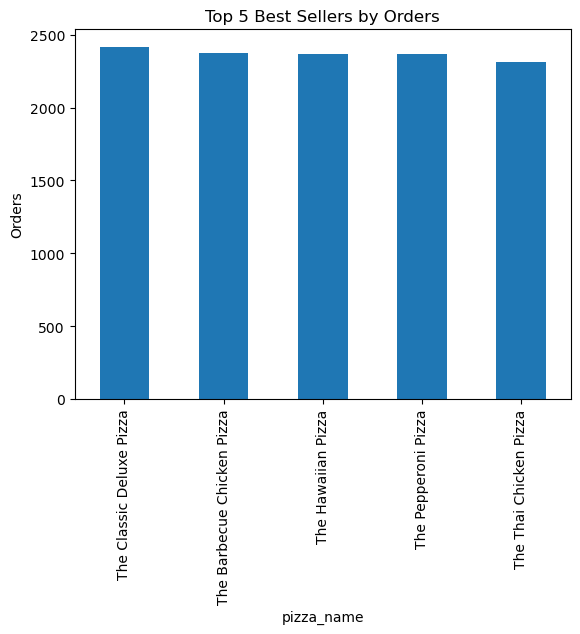

In [52]:
top5_orders = df.groupby('pizza_name')['order_id'].count().sort_values(ascending=False).head(5)

top5_orders.plot(kind='bar')

plt.title("Top 5 Best Sellers by Orders")
plt.ylabel("Orders")
plt.show()

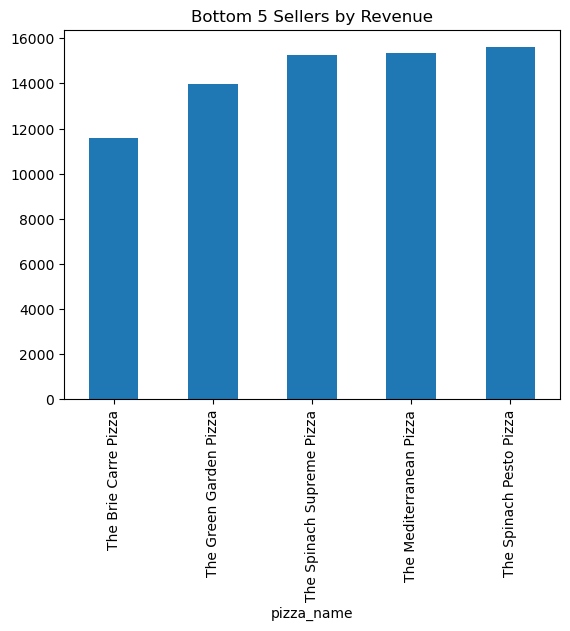

In [54]:
bottom5_revenue = df.groupby('pizza_name')['total_price'].sum().sort_values().head(5)

bottom5_revenue.plot(kind='bar')

plt.title("Bottom 5 Sellers by Revenue")
plt.show()

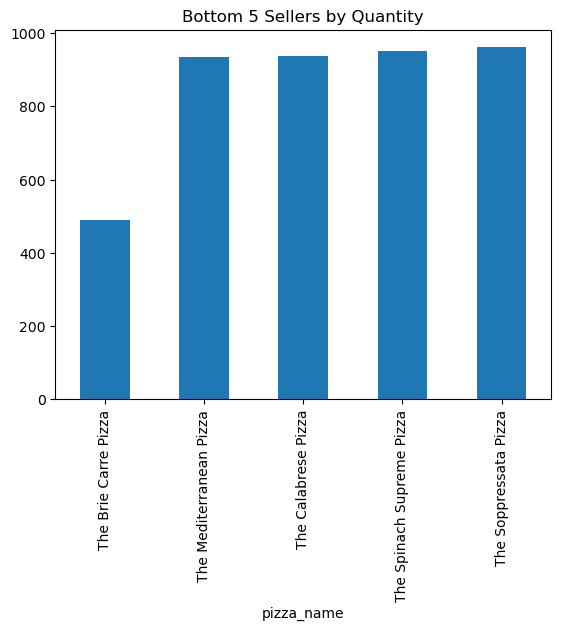

In [56]:
bottom5_quantity = df.groupby('pizza_name')['quantity'].sum().sort_values().head(5)

bottom5_quantity.plot(kind='bar')

plt.title("Bottom 5 Sellers by Quantity")
plt.show()

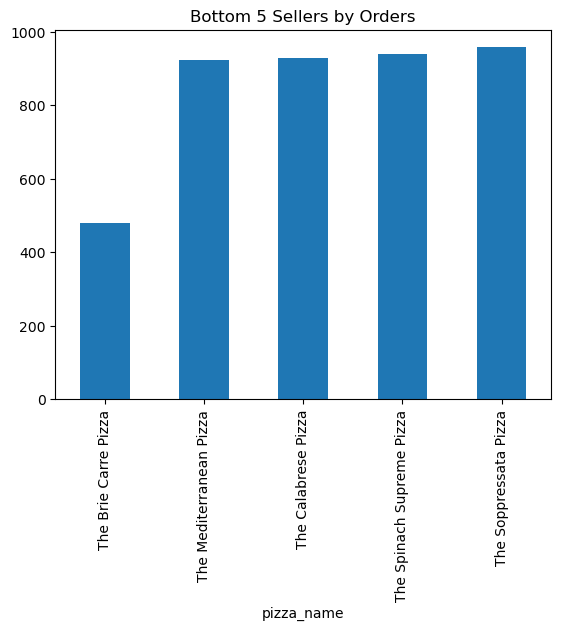

In [58]:
bottom5_orders = df.groupby('pizza_name')['order_id'].count().sort_values().head(5)

bottom5_orders.plot(kind='bar')

plt.title("Bottom 5 Sellers by Orders")
plt.show()